In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

In [ ]:
# Muat dataset
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv('heart.csv')
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
# Cek nilai null
print("Missing values:\n", df.isnull().sum())

# Label encoding untuk fitur kategorikal
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# Tentukan fitur dan target
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Buat model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
#Latih model
rf.fit(X_train, y_train)

#evaluasi model
accuracy = rf.score(X_test, y_test)
print("Akurasi:", accuracy)

Akurasi: 0.8360655737704918


In [ ]:
# Inisialisasi dan training
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

# Prediksi
y_pred = rf.predict(X_test)

# Evaluasi
print("Classification Report (Random Forest):\n", classification_report(y_test, y_pred))
print("Accuracy (Test):", accuracy_score(y_test, y_pred))
print("Accuracy (Train):", accuracy_score(y_train, rf.predict(X_train)))  # Untuk cek overfitting


Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

Accuracy (Test): 0.8852459016393442
Accuracy (Train): 0.9090909090909091


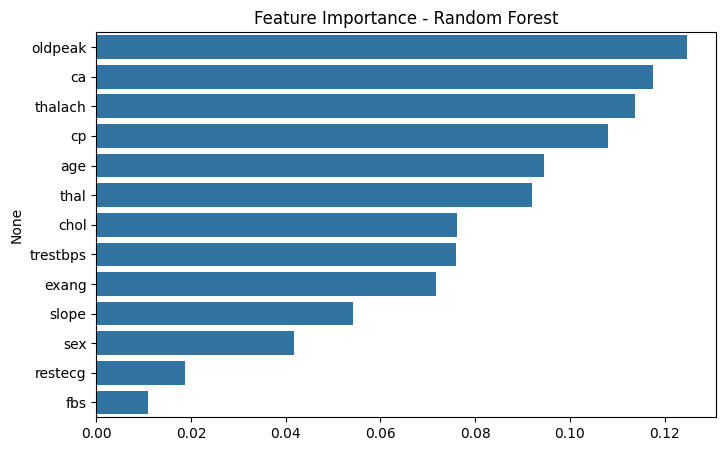

In [ ]:
#Melihat fitur yang penting
best_rf = grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:

# Ambil feature importance dan urutkan
importances = rf.feature_importances_
feature_names = X.columns
important_features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Ambil 5 fitur teratas
top_features = important_features_df['Feature'].head(5).tolist()
print("5 fitur paling penting:", top_features)

# Buat subset data hanya dengan 5 fitur terpenting
X_train_sel = pd.DataFrame(X_train, columns=feature_names)[top_features]
X_test_sel = pd.DataFrame(X_test, columns=feature_names)[top_features]

# Training ulang Random Forest dengan fitur ini
rf_sel = RandomForestClassifier(random_state=42)
rf_sel.fit(X_train_sel, y_train)
y_pred_sel = rf_sel.predict(X_test_sel)

# Evaluasi
from sklearn.metrics import classification_report
print("Classification Report (Top 5 Features):\n", classification_report(y_test, y_pred_sel))


5 fitur paling penting: ['oldpeak', 'thalach', 'ca', 'cp', 'thal']
Classification Report (Top 5 Features):
               precision    recall  f1-score   support

           0       0.81      0.72      0.76        29
           1       0.77      0.84      0.81        32

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



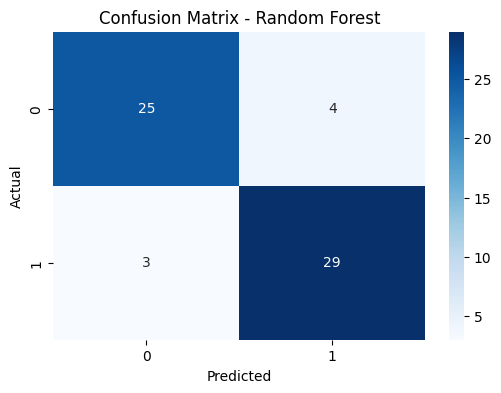

In [ ]:
# CONFUSION MATRIX PLOT
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion(y_test, y_pred, "Confusion Matrix - Random Forest")

In [ ]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}
grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

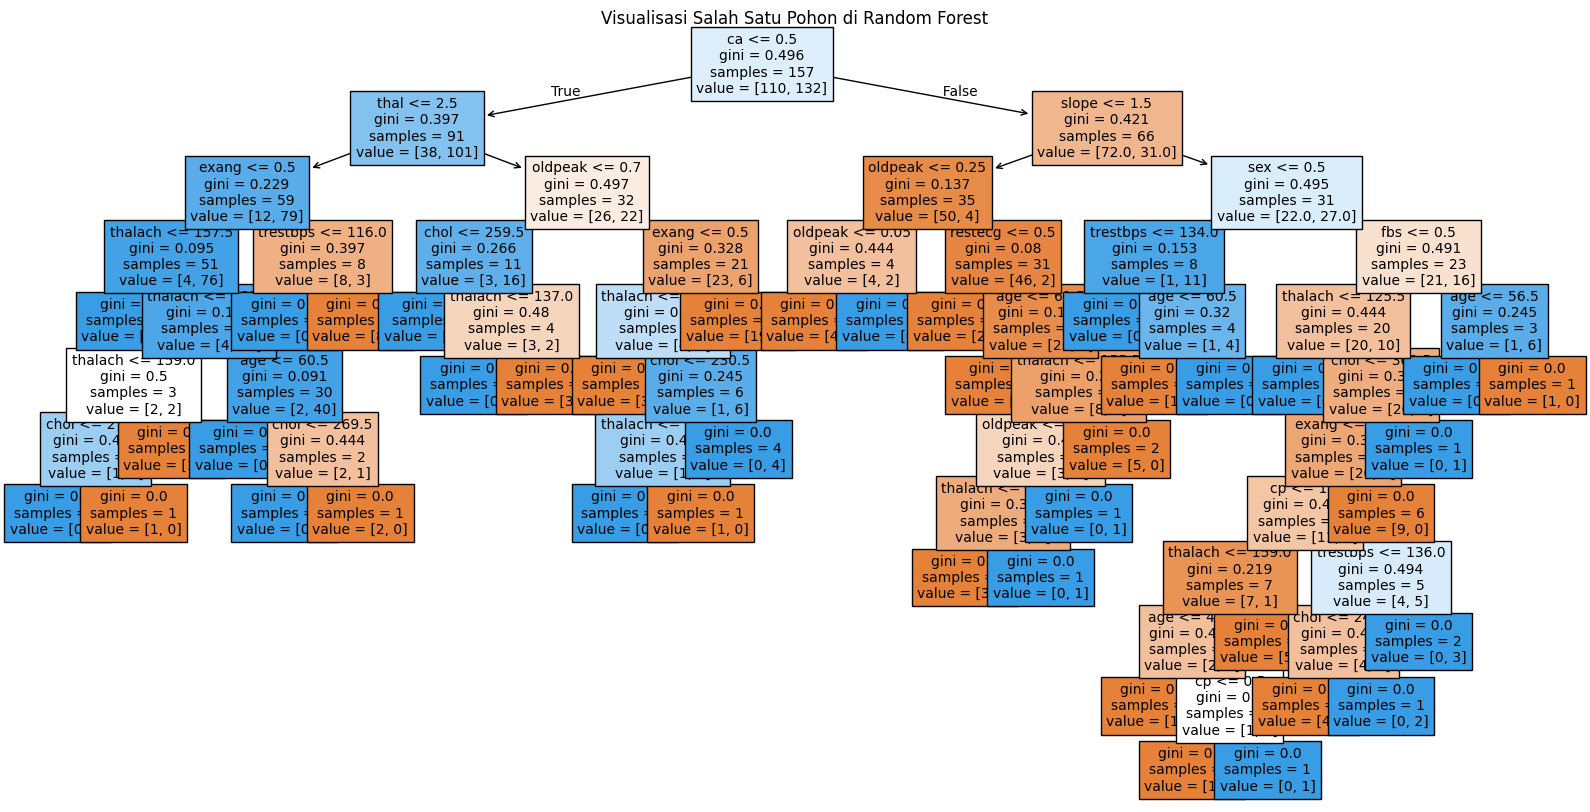

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Pastikan model sudah dilatih
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Visualisasi salah satu pohon
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=X.columns, filled=True, fontsize=10)
plt.title("Visualisasi Salah Satu Pohon di Random Forest")
plt.show()


In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix

#hitung Akurasi
accurasy = accuracy_score(y_test, y_pred)
print("Akurasi:", accuracy)

Akurasi: 0.8360655737704918


In [ ]:
#cetak Laporanklasifikasi
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [ ]:
#Cetak Matriks Konfusi
print("Matriks Konfusi:")
print(confusion_matrix(y_test, y_pred))

Matriks Konfusi:
[[24  5]
 [ 5 27]]


In [ ]:
#evaluasi model
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Train Accuracy:", best_rf.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred))

#mse = mean_squared_error(y_test, y_pred)
#r2 = r2_score(y_test, y_pred)

#print("Mean Squared Error:", mse)
#print("R-squared:", r2)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Train Accuracy: 1.0
Test Accuracy : 0.8688524590163934


In [ ]:
#buat dataframe untuk hasil prediksi
df_pred = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=X_test.index)

df_pred = pd.concat([X_test, df_pred], axis=1)

#cetak dataframe hasil prediksi
print(df_pred)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
179   57    1   0       150   276    0        0      112      1      0.6   
228   59    1   3       170   288    0        0      159      0      0.2   
111   57    1   2       150   126    1        1      173      0      0.2   
246   56    0   0       134   409    0        0      150      1      1.9   
60    71    0   2       110   265    1        0      130      0      0.0   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
249   69    1   2       140   254    0        0      146      0      2.0   
104   50    1   2       129   196    0        1      163      0      0.0   
300   68    1   0       144   193    1        1      141      0      3.4   
193   60    1   0       145   282    0        0      142      1      2.8   
184   50    1   0       150   243    0        0      128      0      2.6   

     slope  ca  thal  Actual  Predicted  
179      1   1     1       0          0  
228